In [1]:
# ---- Reset TensorFlow / GPU memory state before rebuilding model ----
import gc
import tensorflow as tf

tf.keras.backend.clear_session()
gc.collect()

gpus = tf.config.experimental.list_physical_devices("GPU")
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth:", e)

print("Session cleared and GPU memory growth enabled.")

2026-03-11 19:14:54.626621: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-11 19:14:54.684285: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 19:14:56.128416: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Session cleared and GPU memory growth enabled.


# 1. Import the necessery libraries


In [2]:
!sudo nvidia-smi

Wed Mar 11 19:14:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro RTX 4000                Off |   00000000:18:00.0 Off |                  N/A |
| 30%   34C    P8             10W /  125W |    6761MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # use GPU 1 only

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("Visible GPUs:", gpus)

for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except:
        pass


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
# # If you want to use the spesific GPU
# # import os
# # os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # use GPU 1 or GPU 0

# import tensorflow as tf

# # List GPUs available
# gpus = tf.config.list_physical_devices('GPU')
# print("GPUs:", gpus)

# # Check if GPUs are available
# if gpus:
#     print("GPU is available.")
# else:
#     print("GPU is not available.")

# # Set memory growth for each GPU
# for gpu in gpus:
#     tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
import numpy as np
import os
import pandas as pd 
import imageio 
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Conv2DTranspose
from tensorflow.keras.layers import concatenate
from tensorflow.keras import regularizers
from tensorflow.keras.layers import BatchNormalization

# 2. Load and split the data 

In [6]:
import os
import numpy as np
import imageio
from sklearn.model_selection import train_test_split

# -----------------------------
# Paths for each site
# -----------------------------
a58_image_dir = "./data_set/a58_segment2/images/"
a58_mask_dir  = "./data_set/a58_segment2/masks/"

a10_image_dir = "./data_set/a10_segment1/images/"
a10_mask_dir  = "./data_set/a10_segment1/masks/"

# -----------------------------
# Helper function
# -----------------------------
def load_image_mask_lists(image_dir, mask_dir, image_ext=".png", mask_ext=".png"):
    image_filenames = sorted([
        f for f in os.listdir(image_dir)
        if not f.startswith(".") and f.lower().endswith(image_ext)
    ])

    mask_filenames = sorted([
        f for f in os.listdir(mask_dir)
        if not f.startswith(".") and f.lower().endswith(mask_ext)
    ])

    image_dict = {os.path.splitext(f)[0]: os.path.join(image_dir, f) for f in image_filenames}
    mask_dict  = {os.path.splitext(f)[0]: os.path.join(mask_dir, f) for f in mask_filenames}

    common_keys = sorted(set(image_dict.keys()) & set(mask_dict.keys()))

    missing_images = sorted(set(mask_dict.keys()) - set(image_dict.keys()))
    missing_masks  = sorted(set(image_dict.keys()) - set(mask_dict.keys()))

    if missing_images:
        print(f"❌ Missing images for {len(missing_images)} mask(s)")
        print(missing_images[:10])

    if missing_masks:
        print(f"❌ Missing masks for {len(missing_masks)} image(s)")
        print(missing_masks[:10])

    image_list = [image_dict[k] for k in common_keys]
    mask_list  = [mask_dict[k] for k in common_keys]

    return image_list, mask_list

# -----------------------------
# Load each site separately
# -----------------------------
a58_image_list, a58_mask_list = load_image_mask_lists(a58_image_dir, a58_mask_dir)
a10_image_list, a10_mask_list = load_image_mask_lists(a10_image_dir, a10_mask_dir)

# -----------------------------
# A58 -> train / validation
# -----------------------------
train_image_list, validation_image_list, train_mask_list, validation_mask_list = train_test_split(
    a58_image_list,
    a58_mask_list,
    test_size=0.15,
    random_state=42,
    shuffle=True
)

# -----------------------------
# A10 -> test
# -----------------------------
test_image_list = a10_image_list
test_mask_list  = a10_mask_list

# -----------------------------
# Summary
# -----------------------------
print("A58 total images:", len(a58_image_list))
print("A58 total masks :", len(a58_mask_list))

print("A10 total images:", len(a10_image_list))
print("A10 total masks :", len(a10_mask_list))

print("\nTrain images (from A58):", len(train_image_list))
print("Validation images (from A58):", len(validation_image_list))
print("Test images (from A10):", len(test_image_list))

# -----------------------------
# Check mask classes
# -----------------------------
if len(train_mask_list) > 0:
    unique_values_train = np.unique(imageio.v2.imread(train_mask_list[0]))
    print("\nMask classes in one train mask:", unique_values_train)

if len(test_mask_list) > 0:
    unique_values_test = np.unique(imageio.v2.imread(test_mask_list[0]))
    print("Mask classes in one test mask :", unique_values_test)

A58 total images: 8
A58 total masks : 8
A10 total images: 8
A10 total masks : 8

Train images (from A58): 6
Validation images (from A58): 2
Test images (from A10): 8

Mask classes in one train mask: [0 1 2 3]
Mask classes in one test mask : [0 1 2 3]


## Replace the random split with this (later on wiht real data)

In [7]:
# import re

# def extract_x_coord(path):
#     filename = os.path.basename(path)
#     match = re.search(r"x(\d+)", filename)
#     return int(match.group(1))

# # sort A58 tiles by X coordinate
# combined = list(zip(a58_image_list, a58_mask_list))
# combined.sort(key=lambda x: extract_x_coord(x[0]))

# images_sorted = [x[0] for x in combined]
# masks_sorted  = [x[1] for x in combined]

# split_index = int(len(images_sorted) * 0.85)

# train_image_list = images_sorted[:split_index]
# train_mask_list  = masks_sorted[:split_index]

# validation_image_list = images_sorted[split_index:]
# validation_mask_list  = masks_sorted[split_index:]

# 3. explore some images :

In [8]:
def load_and_plot_image_mask(img_path, mask_path):
    """
    Load one image and one mask, print shapes/classes, and plot:
      1) image
      2) colored mask
      3) overlay

    Args:
        img_path (str): path to RGB image (.png)
        mask_path (str): path to mask (.png)

    Returns:
        img (np.ndarray): float32 image in [0, 1], shape (H, W, 3)
        mask (np.ndarray): uint8 class mask, shape (H, W)
    """

    # background, good, fair, poor
    class_colors = np.array([
        [0,   0,   0],    # 0 = background, black
        [0, 255,   0],    # 1 = good, green
        [255, 255, 0],    # 2 = fair, yellow
        [255,   0, 0]     # 3 = poor, red
    ], dtype=np.uint8)

    # Load image
    img = imageio.v2.imread(img_path)

    # Ensure RGB
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.shape[-1] == 4:
        img = img[..., :3]

    img = img.astype(np.float32) / 255.0

    # Load mask
    mask = imageio.v2.imread(mask_path)

    # If mask is RGB/RGBA, take first channel only
    if mask.ndim == 3:
        mask = mask[..., 0]

    mask = mask.astype(np.uint8)

    # Print shapes
    print("Image shape:", img.shape)
    print("Mask shape:", mask.shape)

    # Print unique values
    unique_vals = np.unique(mask)
    print("Unique mask values:", unique_vals)

    # Sanity check
    unexpected = [v for v in unique_vals if v not in [0, 1, 2, 3]]
    if unexpected:
        print("⚠ Unexpected mask values found:", unexpected)

    # Convert mask to color
    mask_color = class_colors[mask]

    # Overlay
    overlay = 0.6 * img + 0.4 * (mask_color.astype(np.float32) / 255.0)

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    ax[0].imshow(img)
    ax[0].set_title("Image")
    ax[0].axis("off")

    ax[1].imshow(mask_color)
    ax[1].set_title("Mask")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

    return img, mask


Sample index: 5
Image: ./data_set/a58_segment2/images/post-harvest_03_2.png
Mask : ./data_set/a58_segment2/masks/post-harvest_03_2.png
Image shape: (312, 312, 3)
Mask shape: (312, 312)
Unique mask values: [0 1 2 3]


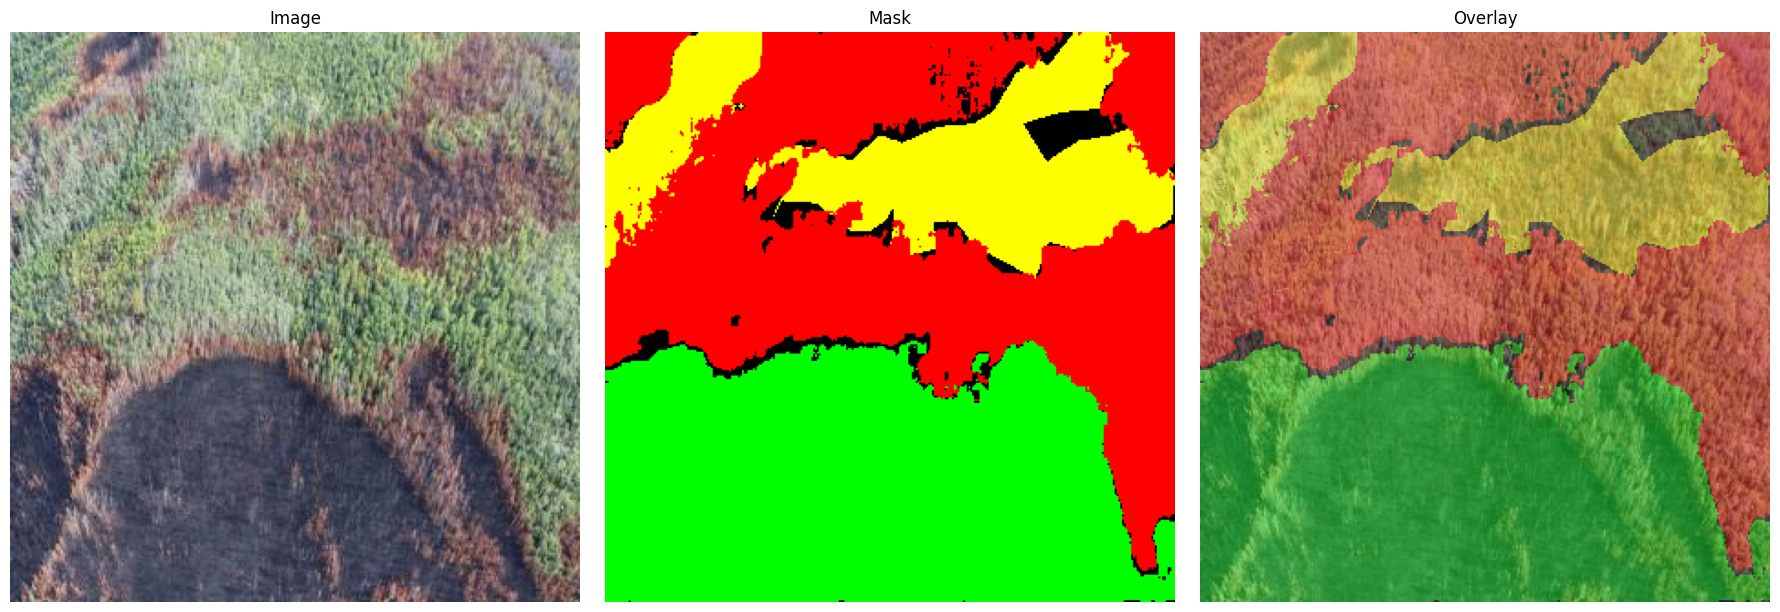

In [9]:
for i in random.sample(range(len(train_image_list)), 1):

    print("\nSample index:", i)
    print("Image:", train_image_list[i])
    print("Mask :", train_mask_list[i])

    load_and_plot_image_mask(
        train_image_list[i],
        train_mask_list[i]
    )

## Create TensorFlow datasets

In [10]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_image_list, train_mask_list))
validation_dataset = tf.data.Dataset.from_tensor_slices((validation_image_list, validation_mask_list))
test_dataset = tf.data.Dataset.from_tensor_slices((test_image_list, test_mask_list))

print("Train dataset size:", len(train_image_list))
print("Validation dataset size:", len(validation_image_list))
print("Test dataset size:", len(test_image_list))


# Inspect one sample from each dataset
for image, mask in train_dataset.take(1):
    print("\nTrain sample:")
    print("Image path:", image.numpy())
    print("Mask path :", mask.numpy())

for image, mask in validation_dataset.take(1):
    print("\nValidation sample:")
    print("Image path:", image.numpy())
    print("Mask path :", mask.numpy())

for image, mask in test_dataset.take(1):
    print("\nTest sample:")
    print("Image path:", image.numpy())
    print("Mask path :", mask.numpy())

Train dataset size: 6
Validation dataset size: 2
Test dataset size: 8

Train sample:
Image path: b'./data_set/a58_segment2/images/post-harvest_01.png'
Mask path : b'./data_set/a58_segment2/masks/post-harvest_01.png'

Validation sample:
Image path: b'./data_set/a58_segment2/images/post-harvest_01_2.png'
Mask path : b'./data_set/a58_segment2/masks/post-harvest_01_2.png'

Test sample:
Image path: b'./data_set/a10_segment1/images/post-harvest_01.png'
Mask path : b'./data_set/a10_segment1/masks/post-harvest_01.png'


I0000 00:00:1773256499.893699  939735 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 703 MB memory:  -> device: 0, name: Quadro RTX 4000, pci bus id: 0000:18:00.0, compute capability: 7.5
I0000 00:00:1773256499.895283  939735 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 606 MB memory:  -> device: 1, name: Quadro RTX 4000, pci bus id: 0000:3b:00.0, compute capability: 7.5
2026-03-11 19:14:59.970237: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-11 19:14:59.986402: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# 4. preprocessing the data

In [11]:
# 4. Preprocessing our data

def process_path(image_path, mask_path):

    # --- Read image ---
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)   # normalize to [0,1]

    # --- Read mask ---
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)          # single channel
    mask = tf.cast(mask, tf.uint8)

    return img, mask


def preprocess(image, mask):

    # Keep higher resolution for UNet
    input_image = tf.image.resize(image, (512, 512), method="bilinear")
    input_mask  = tf.image.resize(mask, (512, 512), method="nearest")

    return input_image, input_mask

# Later on activate this one instead
# def process_path(image_path, mask_path):

#     img = tf.io.read_file(image_path)
#     img = tf.image.decode_png(img, channels=3)
#     img = tf.image.convert_image_dtype(img, tf.float32)

#     mask = tf.io.read_file(mask_path)
#     mask = tf.image.decode_png(mask, channels=1)

#     return img, mask

    
# Apply processing
train_image_ds = train_dataset.map(
    lambda x, y: process_path(x, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_processed_image_ds = train_image_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)


validation_image_ds = validation_dataset.map(
    lambda x, y: process_path(x, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_processed_image_ds = validation_image_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)


test_image_ds = test_dataset.map(
    lambda x, y: process_path(x, y),
    num_parallel_calls=tf.data.AUTOTUNE
)

test_processed_image_ds = test_image_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

print(train_processed_image_ds)
print(validation_processed_image_ds)
print(test_processed_image_ds)

<_ParallelMapDataset element_spec=(TensorSpec(shape=(512, 512, 3), dtype=tf.float32, name=None), TensorSpec(shape=(512, 512, 1), dtype=tf.uint8, name=None))>
<_ParallelMapDataset element_spec=(TensorSpec(shape=(512, 512, 3), dtype=tf.float32, name=None), TensorSpec(shape=(512, 512, 1), dtype=tf.uint8, name=None))>
<_ParallelMapDataset element_spec=(TensorSpec(shape=(512, 512, 3), dtype=tf.float32, name=None), TensorSpec(shape=(512, 512, 1), dtype=tf.uint8, name=None))>


In [12]:
# Add data augmentation (flips, rotations)
# def augment(image, mask):
#     if tf.random.uniform(()) > 0.5:
#         image = tf.image.flip_left_right(image)
#         mask = tf.image.flip_left_right(mask)
#     return image, mask
# train_processed_image_ds = train_processed_image_ds.map(augment)

# Defining mean IoU metric

Overall mean IoU including background

In [13]:
NUM_CLASSES = 4

In [14]:
class MeanIoUMetric(tf.keras.metrics.MeanIoU):
    
    def __init__(self, num_classes=NUM_CLASSES, name="mean_iou", **kwargs):
        super().__init__(num_classes=num_classes, name=name, **kwargs)

    def update_state(self, y_true, y_pred, sample_weight=None):

        # Remove extra mask channel if present
        if y_true.shape.rank == 4:
            y_true = tf.squeeze(y_true, axis=-1)

        # Convert logits → predicted class
        y_pred = tf.argmax(y_pred, axis=-1)

        return super().update_state(y_true, y_pred, sample_weight)

Adding per-class IoU

This immediately tells you:

- which microsite class is easiest

- which class needs more training data

- whether class imbalance is affecting performance

In [15]:
def iou_for_class(class_id, smooth=1e-7):
    
    def metric(y_true, y_pred):
        
        # remove channel dimension if present
        if y_true.shape.rank == 4:
            y_true = tf.squeeze(y_true, axis=-1)

        # predicted class
        y_pred = tf.argmax(y_pred, axis=-1)

        y_true_c = tf.cast(tf.equal(y_true, class_id), tf.float32)
        y_pred_c = tf.cast(tf.equal(y_pred, class_id), tf.float32)

        intersection = tf.reduce_sum(y_true_c * y_pred_c)
        union = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c) - intersection

        return (intersection + smooth) / (union + smooth)

    return metric


# individual class metrics
iou_background = iou_for_class(0)
iou_good       = iou_for_class(1)
iou_fair       = iou_for_class(2)
iou_poor       = iou_for_class(3)

Mean IoU for only good/fair/poor

In [16]:
def mean_iou_no_background(smooth=1e-7):
    
    def metric(y_true, y_pred):
        
        if y_true.shape.rank == 4:
            y_true = tf.squeeze(y_true, axis=-1)

        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.argmax(y_pred, axis=-1, output_type=tf.int32)

        ious = []

        for c in [1, 2, 3]:
            y_true_c = tf.cast(tf.equal(y_true, c), tf.float32)
            y_pred_c = tf.cast(tf.equal(y_pred, c), tf.float32)

            intersection = tf.reduce_sum(y_true_c * y_pred_c)
            union = tf.reduce_sum(y_true_c) + tf.reduce_sum(y_pred_c) - intersection

            iou = (intersection + smooth) / (union + smooth)
            ious.append(iou)

        return tf.reduce_mean(tf.stack(ious))

    metric.__name__ = "mean_iou_fg"
    return metric

mean_iou_fg = mean_iou_no_background()

# 5.  Define The Conv Block For The Contracting Path

In [17]:
def conv_block(inputs, n_filters=32, dropout_prob=0.0, max_pooling=True):

    conv = Conv2D(
        n_filters,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        kernel_initializer=tf.keras.initializers.HeNormal()
    )(inputs)
    conv = BatchNormalization()(conv)

    conv = Conv2D(
        n_filters,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        kernel_initializer=tf.keras.initializers.HeNormal()
    )(conv)
    conv = BatchNormalization()(conv)

    if dropout_prob > 0:
        conv = Dropout(dropout_prob)(conv)

    skip_connection = conv

    if max_pooling:
        next_layer = MaxPooling2D(pool_size=(2, 2))(conv)
    else:
        next_layer = conv

    return next_layer, skip_connection

# 6. Define the upsampling block for the expanding path

In [18]:
def upsampling_block(expansive_input, contractive_input, n_filters=32):

    up = Conv2DTranspose(
        n_filters,
        kernel_size=(3, 3),
        strides=(2, 2),
        padding='same'
    )(expansive_input)

    merge = concatenate([up, contractive_input], axis=-1)

    conv = Conv2D(
        n_filters,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        kernel_initializer=tf.keras.initializers.HeNormal()
    )(merge)
    conv = BatchNormalization()(conv)

    conv = Conv2D(
        n_filters,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        kernel_initializer=tf.keras.initializers.HeNormal()
    )(conv)
    conv = BatchNormalization()(conv)

    return conv

# 7.  Define the U-Net model
It comprises a set of conv blocks and upsampling blocks

In [19]:
# If 512×512 is too heavy on GPU, the first thing to reduce is not image size, but: n_filters=16

def unet_model(input_size=(512, 512, 3), n_filters=32, n_classes=4):

    inputs = Input(shape=input_size)

    # Contracting path
    cblock1 = conv_block(inputs,        n_filters,     dropout_prob=0.1, max_pooling=True)
    cblock2 = conv_block(cblock1[0],  2*n_filters,    dropout_prob=0.1, max_pooling=True)
    cblock3 = conv_block(cblock2[0],  4*n_filters,    dropout_prob=0.2, max_pooling=True)
    cblock4 = conv_block(cblock3[0],  8*n_filters,    dropout_prob=0.2, max_pooling=True)
    cblock5 = conv_block(cblock4[0], 16*n_filters,    dropout_prob=0.3, max_pooling=False)

    # Expanding path
    ublock6 = upsampling_block(cblock5[0], cblock4[1], 8 * n_filters)
    ublock7 = upsampling_block(ublock6,    cblock3[1], 4 * n_filters)
    ublock8 = upsampling_block(ublock7,    cblock2[1], 2 * n_filters)
    ublock9 = upsampling_block(ublock8,    cblock1[1], 1 * n_filters)

    conv9 = Conv2D(
        n_filters,
        kernel_size=(3, 3),
        activation='relu',
        padding='same',
        kernel_initializer='he_normal'
    )(ublock9)

    outputs = Conv2D(
        n_classes,
        kernel_size=(1, 1),
        activation='softmax',
        padding='same'
    )(conv9)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    return model

In [20]:
IMG_SIZE = 512
num_channels = 3

unet = unet_model((IMG_SIZE, IMG_SIZE, num_channels))

# 8. The model is ready!

In [21]:
unet.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 512, 512,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 512, 512,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 256, 256,  │          0 │ dropout[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 256, 256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 256, 256,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 128, 128,  │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 128, 128,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_5[0][0]  

 Total params: 8,651,620 (33.00 MB)

 Trainable params: 8,645,732 (32.98 MB)

 Non-trainable params: 5,888 (23.00 KB)

# Compiling the model

In [22]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

unet.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        'accuracy',
        MeanIoUMetric(),
        mean_iou_fg,
        tf.keras.metrics.MeanMetricWrapper(iou_good, name="iou_good"),
        tf.keras.metrics.MeanMetricWrapper(iou_fair, name="iou_fair"),
        tf.keras.metrics.MeanMetricWrapper(iou_poor, name="iou_poor")
        # iou_good, 
        # iou_fair, 
        # iou_poor
    ]
)

In [23]:
EPOCHS = 500
BATCH_SIZE = 4 # If GPU memory allows: try 8, If get out-of-memory: reduce to 2
BUFFER_SIZE = len(train_image_list)

# Train dataset
train_dataset = (
    train_processed_image_ds
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset
validation_dataset = (
    validation_processed_image_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Train element spec:", train_processed_image_ds.element_spec)
print("Validation element spec:", validation_processed_image_ds.element_spec)

# Callbacks
# callbacks = [
#     tf.keras.callbacks.EarlyStopping(
#         monitor="val_mean_iou_fg",
#         mode="max",
#         patience=15,
#         restore_best_weights=True
#     ),
#     tf.keras.callbacks.ModelCheckpoint(
#         "best_unet_model.keras",
#         monitor="val_mean_iou_fg",
#         mode="max",
#         save_best_only=True
#     ),
#     tf.keras.callbacks.ReduceLROnPlateau(
#         monitor="val_mean_iou_fg",
#         mode="max",
#         factor=0.5,
#         patience=5,
#         min_lr=1e-6,
#         verbose=1
#     )
# ]

model_history = unet.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    # callbacks=callbacks
)

Train element spec: (TensorSpec(shape=(512, 512, 3), dtype=tf.float32, name=None), TensorSpec(shape=(512, 512, 1), dtype=tf.uint8, name=None))
Validation element spec: (TensorSpec(shape=(512, 512, 3), dtype=tf.float32, name=None), TensorSpec(shape=(512, 512, 1), dtype=tf.uint8, name=None))
Epoch 1/500


2026-03-11 19:15:10.667452: I external/local_xla/xla/service/service.cc:163] XLA service 0x7907ec004870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-11 19:15:10.667485: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Quadro RTX 4000, Compute Capability 7.5
2026-03-11 19:15:10.667492: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (1): Quadro RTX 4000, Compute Capability 7.5
2026-03-11 19:15:11.059774: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-11 19:15:11.779157: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-03-11 19:15:12.680228: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91

UnknownError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/usr/lib/python3.12/runpy.py", line 198, in _run_module_as_main

  File "/usr/lib/python3.12/runpy.py", line 88, in _run_code

  File "/home/eghase02/venvs/tf220/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/eghase02/venvs/tf220/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/eghase02/venvs/tf220/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start

  File "/home/eghase02/venvs/tf220/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 641, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1987, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/home/eghase02/venvs/tf220/lib/python3.12/site-packages/i

In [ ]:
plt.plot(model_history.history["accuracy"])

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(model_history.history["mean_iou_fg"], label="Train mean_iou_fg")
plt.plot(model_history.history["val_mean_iou_fg"], label="Validation mean_iou_fg")
plt.xlabel("Epoch")
plt.ylabel("Mean IoU (good/fair/poor)")
plt.title("Training and Validation Foreground Mean IoU")
plt.legend()
plt.grid(True)
plt.show()

# Visually check:

- Is the model detecting good/fair/poor microsites correctly?

- Are boundaries reasonable?

- Is it predicting background everywhere?

In [ ]:
CLASS_COLORS = np.array([
    [0, 0, 0],        # background
    [0, 255, 0],      # good, green
    [255, 255, 0],    # fair, yellow
    [255, 0, 0]       # poor, red
], dtype=np.uint8)


def mask_to_color(mask):
    """Convert mask (H,W) or (H,W,1) to RGB"""
    
    if tf.is_tensor(mask):
        mask = mask.numpy()
        
    if mask.ndim == 3 and mask.shape[-1] == 1:
        mask = mask[...,0]
        
    mask = mask.astype(np.int32)
    return CLASS_COLORS[mask]


def create_mask(pred_mask):
    """Convert softmax output to class mask"""
    
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    
    return pred_mask[0].numpy().astype(np.uint8)


def overlay_mask(image, mask_color, alpha=0.4):
    """
    Overlay colored mask on image
    """
    
    if tf.is_tensor(image):
        image = image.numpy()
        
    image = (image * 255).astype(np.uint8)
    
    overlay = (1 - alpha) * image + alpha * mask_color
    return overlay.astype(np.uint8)


def display_prediction(image, true_mask, pred_mask):
    
    true_color = mask_to_color(true_mask)
    pred_color = mask_to_color(pred_mask)
    
    overlay = overlay_mask(image, pred_color)

    plt.figure(figsize=(18,6))

    titles = [
        "Input Image",
        "Ground Truth",
        "Prediction",
        "Prediction Overlay"
    ]

    images = [
        image,
        true_color,
        pred_color,
        overlay
    ]

    for i in range(4):
        plt.subplot(1,4,i+1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def show_predictions(dataset, num=3):

    for image, mask in dataset.take(num):

        pred = unet.predict(image, verbose=0)
        pred_mask = create_mask(pred)

        display_prediction(
            image[0],
            mask[0],
            pred_mask
        )

In [ ]:
print("----- training_dataset results---------")
show_predictions(train_dataset, 6)
print("----- validation_dataset results---------")
show_predictions(validation_dataset, 6)

In [ ]:
results = unet.evaluate(validation_dataset, return_dict=True)

for k,v in results.items():
    print(f"{k}: {v:.4f}")

In [ ]:
test_dataset = (
    test_processed_image_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_results = unet.evaluate(test_dataset)
print(test_results)

In [ ]:
test_dataset = (
    test_processed_image_ds
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_results = unet.evaluate(test_dataset, return_dict=True)

print("UNet Test Evaluation on A10:")
for k, v in test_results.items():
    print(f"{k}: {v:.4f}")

In [ ]:
print("----- test_dataset results---------")
show_predictions(test_dataset, num=5)

In [ ]:
test_results = unet.evaluate(test_dataset)

test_mean_iou_fg = test_results[3]   # adjust index if needed

plt.figure(figsize=(8,5))

plt.plot(model_history.history["mean_iou_fg"], label="Train")
plt.plot(model_history.history["val_mean_iou_fg"], label="Validation")

plt.axhline(
    y=test_mean_iou_fg,
    color="red",
    linestyle="--",
    label="Test IoU"
)

plt.xlabel("Epoch")
plt.ylabel("Mean IoU (good/fair/poor)")
plt.title("Train / Validation / Test IoU")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os
import numpy as np
from PIL import Image

save_dir = "./output/test_predictions_a10_segment1"
os.makedirs(save_dir, exist_ok=True)

counter = 0

for images, masks in test_dataset:
    pred_probs = unet.predict(images, verbose=0)
    pred_classes = tf.argmax(pred_probs, axis=-1).numpy()

    for i in range(pred_classes.shape[0]):
        pred_mask = pred_classes[i].astype(np.uint8)
        Image.fromarray(pred_mask).save(
            os.path.join(save_dir, f"pred_mask_{counter:04d}.png")
        )
        counter += 1

print(f"Saved {counter} predicted masks to {save_dir}")

# Confirm the prediction mask is correct

In [ ]:
print("dtype:", pred_mask.dtype)
print("shape:", pred_mask.shape)
print("unique:", np.unique(pred_mask))